# CloudDrift — Day 3: Feature Engineering Pipeline

This notebook builds and validates the 68-feature engineering pipeline
that transforms raw SMD server telemetry into the feature matrix used
to train the Isolation Forest and TCN Autoencoder.

**Input:** Raw SMD DataFrame (5 metric columns, [0,1] range)
**Output:** 68 engineered features + fitted normalization pipeline

| Feature category | Count | Description |
|-----------------|-------|-------------|
| Raw metrics | 5 | cpu_util, mem_util, net_io_in, net_io_out, disk_io |
| Rolling stats | 60 | mean, std, z-score, roc, range_ratio × 3 windows × 5 metrics |
| Cross-metric | 3 | CPU-mem correlation, CPU-net ratio, composite volatility |
| **Total** | **68** | **→ TCN input_dim=68** |

In [1]:
import os, sys, json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_root = Path('.').resolve()
while not (_root / 'src').exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
os.chdir(_root)

from src.data.ingestion import load_smd_dataset
from src.data.validation import validate_smd_schema, define_temporal_split_per_series
from src.features.engineering import (
    build_alibaba_features, get_feature_columns,
    build_feature_pipeline, apply_feature_pipeline,
    save_feature_pipeline, load_feature_pipeline,
    RobustPercentileNormalizer,
)

plt.rcParams['figure.facecolor'] = 'white'
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

MACHINES = [f'machine-1-{i}' for i in range(1, 8)]
ARTIFACTS_DIR = _root / 'artifacts'
print(f'Project root: {_root}')

Project root: /home/lobora/projects/clouddrift


## 1. Load and Validate Raw Data

In [2]:
raw_df = load_smd_dataset(machines=MACHINES)
raw_df = validate_smd_schema(raw_df)
print(f'Raw data: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns')
print(f'Metric columns: {["cpu_util","mem_util","net_io_in","net_io_out","disk_io"]}')

Raw data: 341,346 rows × 9 columns
Metric columns: ['cpu_util', 'mem_util', 'net_io_in', 'net_io_out', 'disk_io']


## 2. Build Features

`build_alibaba_features()` processes each machine independently to prevent
cross-series contamination. For each of the 5 metric columns it computes:
- **Rolling mean, std, z-score** at short (1-step), mid (3-step), long (6-step) windows
- **Rate of change** (first difference)
- **Range ratio** at mid and long windows

Then adds 3 cross-metric features that capture relationships between metrics
invisible when each signal is analysed in isolation.

In [3]:
feat_df = build_alibaba_features(raw_df, group_col='machine_id')
feature_cols = get_feature_columns(feat_df)

print(f'Feature matrix: {feat_df.shape[0]:,} rows × {feat_df.shape[1]} columns')
print(f'Feature columns: {len(feature_cols)} (used for model training)')
print(f'Metadata columns: {feat_df.shape[1] - len(feature_cols)} (excluded from training)')

Feature matrix: 341,346 rows × 72 columns
Feature columns: 68 (used for model training)
Metadata columns: 4 (excluded from training)


## 3. All 68 Feature Columns

The full feature set grouped by category. These column names map
directly to the Isolation Forest input and the TCN `input_dim=68`.

In [4]:
# Group feature columns by category
raw_metrics  = [c for c in feature_cols if c in ['cpu_util','mem_util','net_io_in','net_io_out','disk_io']]
cross_metric = [c for c in feature_cols if c in ['cpu_mem_corr_long','cpu_net_ratio','volatility_score']]
rolling      = [c for c in feature_cols if c not in raw_metrics + cross_metric]

print(f'Raw metric columns ({len(raw_metrics)}):')
for c in raw_metrics: print(f'  {c}')

print(f'\nCross-metric columns ({len(cross_metric)}):')
for c in cross_metric: print(f'  {c}')

print(f'\nRolling feature columns ({len(rolling)}):',
      '(5 metrics × 12 features each)')
# Show for cpu_util only as representative
cpu_rolling = [c for c in rolling if c.startswith('cpu_util')]
print('  cpu_util rolling features (representative):')
for c in sorted(cpu_rolling): print(f'    {c}')

Raw metric columns (5):
  cpu_util
  disk_io
  mem_util
  net_io_in
  net_io_out

Cross-metric columns (3):
  cpu_mem_corr_long
  cpu_net_ratio
  volatility_score

Rolling feature columns (60): (5 metrics × 12 features each)
  cpu_util rolling features (representative):
    cpu_util_mean_long
    cpu_util_mean_mid
    cpu_util_mean_short
    cpu_util_range_ratio_long
    cpu_util_range_ratio_mid
    cpu_util_roc
    cpu_util_std_long
    cpu_util_std_mid
    cpu_util_std_short
    cpu_util_zscore_long
    cpu_util_zscore_mid
    cpu_util_zscore_short


In [5]:
print(rolling)

['cpu_util_mean_long', 'cpu_util_mean_mid', 'cpu_util_mean_short', 'cpu_util_range_ratio_long', 'cpu_util_range_ratio_mid', 'cpu_util_roc', 'cpu_util_std_long', 'cpu_util_std_mid', 'cpu_util_std_short', 'cpu_util_zscore_long', 'cpu_util_zscore_mid', 'cpu_util_zscore_short', 'disk_io_mean_long', 'disk_io_mean_mid', 'disk_io_mean_short', 'disk_io_range_ratio_long', 'disk_io_range_ratio_mid', 'disk_io_roc', 'disk_io_std_long', 'disk_io_std_mid', 'disk_io_std_short', 'disk_io_zscore_long', 'disk_io_zscore_mid', 'disk_io_zscore_short', 'mem_util_mean_long', 'mem_util_mean_mid', 'mem_util_mean_short', 'mem_util_range_ratio_long', 'mem_util_range_ratio_mid', 'mem_util_roc', 'mem_util_std_long', 'mem_util_std_mid', 'mem_util_std_short', 'mem_util_zscore_long', 'mem_util_zscore_mid', 'mem_util_zscore_short', 'net_io_in_mean_long', 'net_io_in_mean_mid', 'net_io_in_mean_short', 'net_io_in_range_ratio_long', 'net_io_in_range_ratio_mid', 'net_io_in_roc', 'net_io_in_std_long', 'net_io_in_std_mid', '

## 4. Rolling Feature Example — cpu_util

Visualising the effect of rolling features on a single metric.
The raw signal is noisy; rolling mean smooths it. Z-score captures
how far the current value is from recent history — a key anomaly signal.

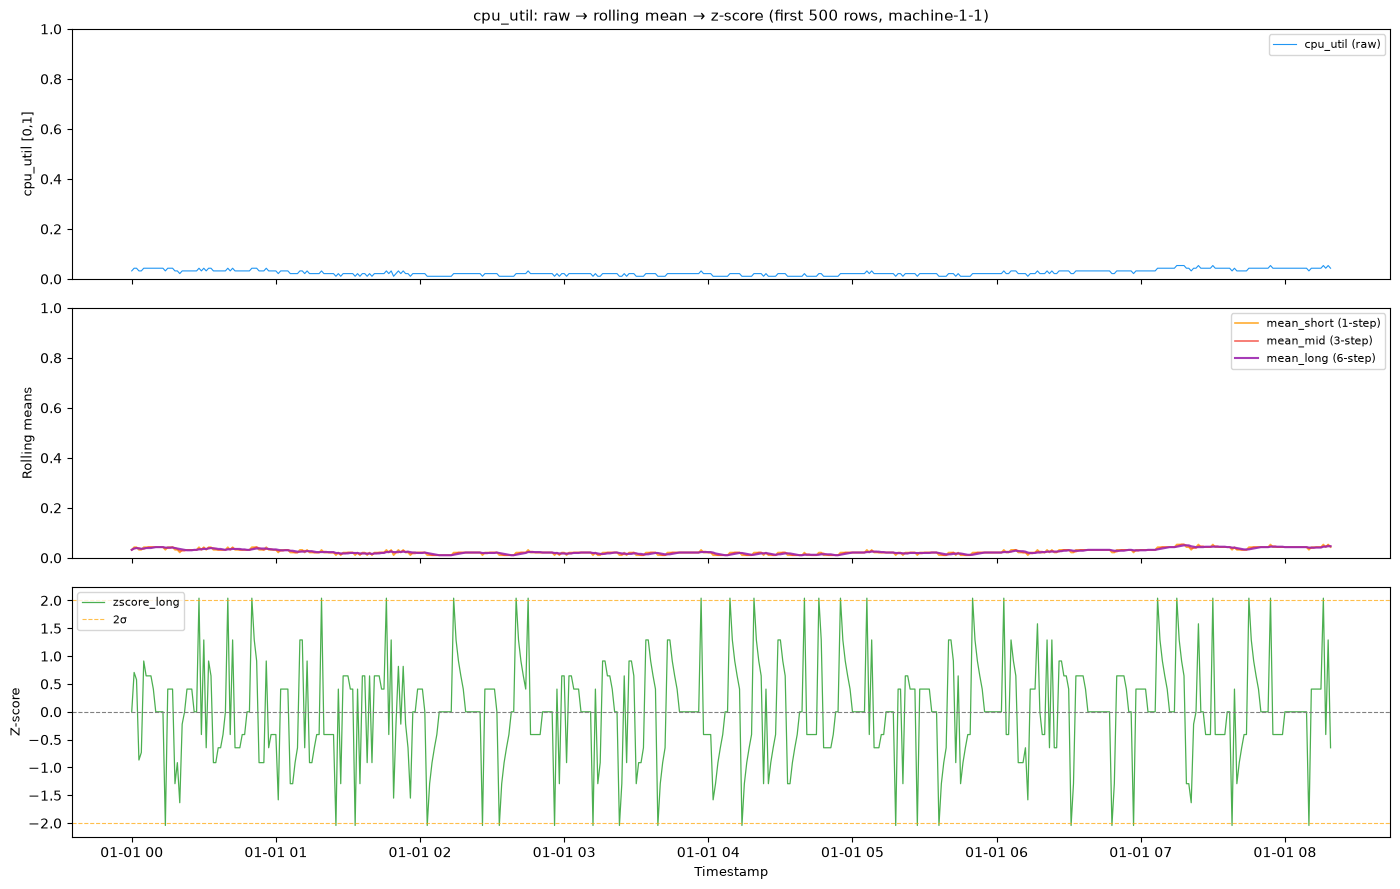

Rolling feature visualization complete.


In [6]:
m1_feat = feat_df[feat_df['machine_id'] == 'machine-1-1'].head(500).copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Raw metric
axes[0].plot(m1_feat['timestamp'], m1_feat['cpu_util'],
             color='#2196F3', linewidth=0.8, label='cpu_util (raw)')
axes[0].set_ylabel('cpu_util [0,1]', fontsize=9)
axes[0].legend(fontsize=8); axes[0].set_ylim(0, 1)

# Rolling means
axes[1].plot(m1_feat['timestamp'], m1_feat['cpu_util_mean_short'],
             color='#FF9800', linewidth=1.2, label='mean_short (1-step)', alpha=0.8)
axes[1].plot(m1_feat['timestamp'], m1_feat['cpu_util_mean_mid'],
             color='#F44336', linewidth=1.2, label='mean_mid (3-step)', alpha=0.8)
axes[1].plot(m1_feat['timestamp'], m1_feat['cpu_util_mean_long'],
             color='#9C27B0', linewidth=1.5, label='mean_long (6-step)', alpha=0.9)
axes[1].set_ylabel('Rolling means', fontsize=9)
axes[1].legend(fontsize=8); axes[1].set_ylim(0, 1)

# Z-score
axes[2].plot(m1_feat['timestamp'], m1_feat['cpu_util_zscore_long'],
             color='#4CAF50', linewidth=0.9, label='zscore_long')
axes[2].axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
axes[2].axhline(y=2, color='orange', linewidth=0.8, linestyle='--', alpha=0.7, label='2σ')
axes[2].axhline(y=-2, color='orange', linewidth=0.8, linestyle='--', alpha=0.7)
axes[2].set_ylabel('Z-score', fontsize=9)
axes[2].set_xlabel('Timestamp', fontsize=9)
axes[2].legend(fontsize=8)

axes[0].set_title('cpu_util: raw → rolling mean → z-score (first 500 rows, machine-1-1)',
                   fontsize=11)
plt.tight_layout()
plt.show()
print('Rolling feature visualization complete.')

## 5. Cross-Metric Features

Three features capture relationships between metrics:
- **cpu_mem_corr_long:** rolling Pearson correlation of CPU and memory. Breakdown in this
  correlation (normally ~0.7) signals an unusual process consuming one resource without the other.
- **cpu_net_ratio:** CPU / network_in. High network traffic without CPU load indicates
  anomalous I/O-heavy behaviour.
- **volatility_score:** mean of all metric std_long values. All metrics simultaneously
  more volatile than normal is a stronger anomaly signal than any single metric alone.

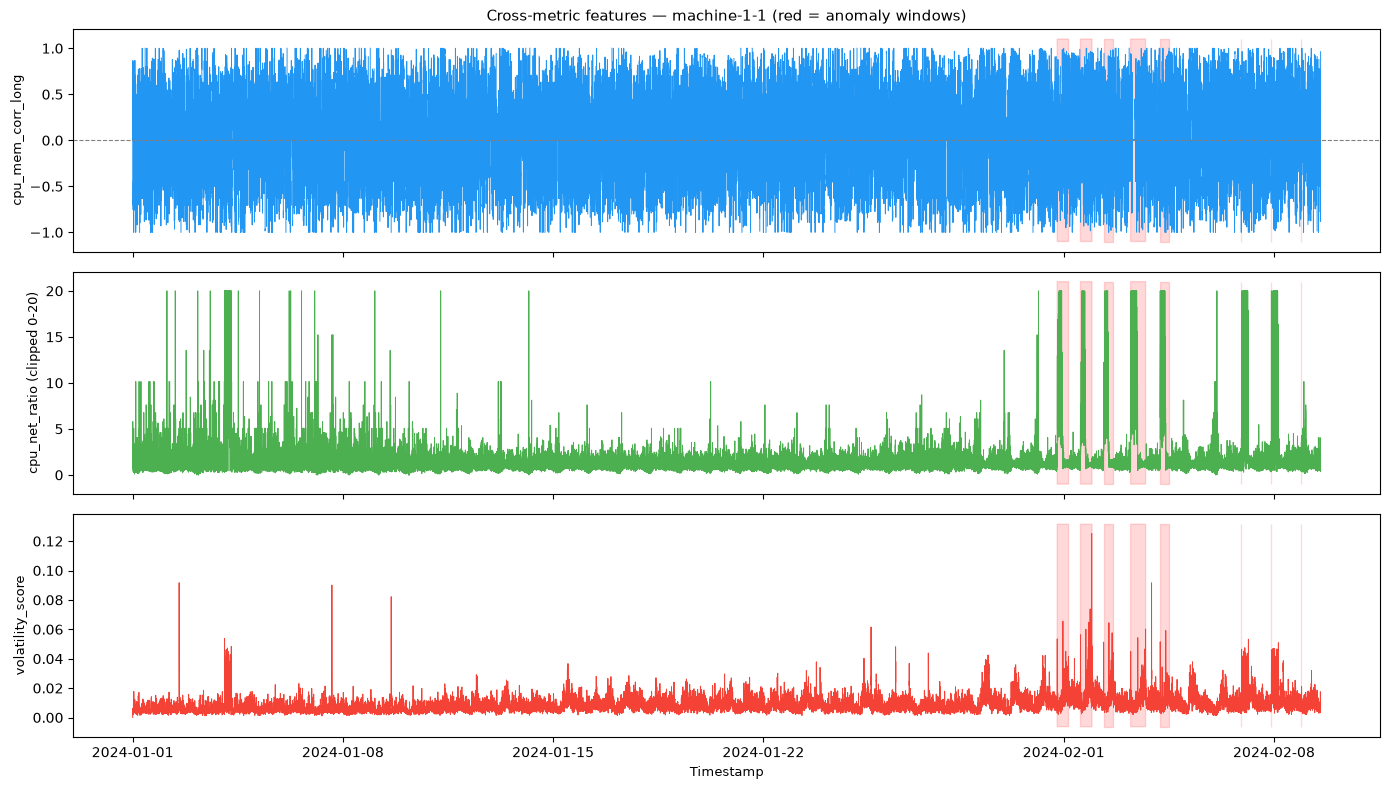

In [7]:
cross_df = feat_df[feat_df['machine_id'] == 'machine-1-1'].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(cross_df['timestamp'], cross_df['cpu_mem_corr_long'],
             color='#2196F3', linewidth=0.7)
axes[0].set_ylabel('cpu_mem_corr_long', fontsize=9)
axes[0].axhline(y=0, color='gray', linewidth=0.8, linestyle='--')

axes[1].plot(cross_df['timestamp'], cross_df['cpu_net_ratio'].clip(0, 20),
             color='#4CAF50', linewidth=0.7)
axes[1].set_ylabel('cpu_net_ratio (clipped 0-20)', fontsize=9)

axes[2].plot(cross_df['timestamp'], cross_df['volatility_score'],
             color='#F44336', linewidth=0.7)
axes[2].set_ylabel('volatility_score', fontsize=9)
axes[2].set_xlabel('Timestamp', fontsize=9)

# Highlight anomaly windows
for ax in axes:
    ax.fill_between(cross_df['timestamp'], ax.get_ylim()[0], ax.get_ylim()[1],
                    where=cross_df['is_anomaly'].values,
                    alpha=0.15, color='red')

axes[0].set_title('Cross-metric features — machine-1-1 (red = anomaly windows)', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Feature Pipeline: Fit and Normalize

`RobustPercentileNormalizer` clips each feature to its [p1, p99] range
from the training normal rows, then scales to [0, 1]. This makes the
Isolation Forest and TCN robust to outliers without discarding them.

In [8]:
# Temporal split
train_df, val_df, test_df = define_temporal_split_per_series(
    feat_df, group_col='machine_id', train_pct=0.70, val_pct=0.15
)

print(f'Train: {len(train_df):,} rows ({train_df["is_anomaly"].mean()*100:.2f}% anomaly)')
print(f'Val:   {len(val_df):,} rows ({val_df["is_anomaly"].mean()*100:.2f}% anomaly)')
print(f'Test:  {len(test_df):,} rows ({test_df["is_anomaly"].mean()*100:.2f}% anomaly)')

# Fit pipeline on training normal rows only
train_normal = train_df[~train_df['is_anomaly']]
print()
print(f'Fitting pipeline on {len(train_normal):,} training normal rows...')
pipeline = build_feature_pipeline(train_normal, feature_cols)

# Apply to all splits
train_norm = apply_feature_pipeline(pipeline, train_df, feature_cols)
val_norm   = apply_feature_pipeline(pipeline, val_df,   feature_cols)
test_norm  = apply_feature_pipeline(pipeline, test_df,  feature_cols)

print(f'Normalization applied. Feature value range after pipeline:')
print(f'  Train: [{train_norm[feature_cols].min().min():.4f}, {train_norm[feature_cols].max().max():.4f}]')
print(f'  Val:   [{val_norm[feature_cols].min().min():.4f}, {val_norm[feature_cols].max().max():.4f}]')
print(f'  Test:  [{test_norm[feature_cols].min().min():.4f}, {test_norm[feature_cols].max().max():.4f}]')

Train: 238,938 rows (1.27% anomaly)
Val:   51,203 rows (6.04% anomaly)
Test:  51,205 rows (9.49% anomaly)

Fitting pipeline on 235,908 training normal rows...


/home/lobora/projects/clouddrift/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/home/lobora/projects/clouddrift/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


Normalization applied. Feature value range after pipeline:
  Train: [0.0000, 1.0000]
  Val:   [0.0000, 1.0000]
  Test:  [0.0000, 1.0000]


## 7. Normalizer Bounds Inspection

The normalizer stores per-feature [p1, p99] bounds from the training
distribution. Values outside these bounds are clipped. One known edge case:
`cpu_mem_corr_long` produces NaN bounds at series boundaries (rolling Pearson
correlation requires at least 2 data points). A guard in `fit()` replaces
these with (0.0, 1.0).

In [9]:
normalizer = pipeline.named_steps['normalizer']

print('Sample normalizer bounds (first 10 features):')
print(f'  {"Feature":<35} {"Lower (p1)":>12} {"Upper (p99)":>12}')
print('  ' + '-' * 62)
for col in list(normalizer.bounds_.keys())[:10]:
    lo, hi = normalizer.bounds_[col]
    import math
    nan_flag = ' ← patched' if math.isnan(lo) or math.isnan(hi) else ''
    print(f'  {col:<35} {lo:>12.6f} {hi:>12.6f}{nan_flag}')

nan_count = sum(1 for lo, hi in normalizer.bounds_.values()
                if math.isnan(lo) or math.isnan(hi))
print(f'\nTotal features: {len(normalizer.bounds_)}')
print(f'NaN bounds:     {nan_count} (cpu_mem_corr_long — patched to (0.0, 1.0) at runtime)')

Sample normalizer bounds (first 10 features):
  Feature                               Lower (p1)  Upper (p99)
  --------------------------------------------------------------
  cpu_mem_corr_long                       0.000000     1.000000
  cpu_net_ratio                           0.000000    56.028727
  cpu_util                                0.000000     0.397849
  cpu_util_mean_long                      0.003333     0.363636
  cpu_util_mean_mid                       0.003333     0.373333
  cpu_util_mean_short                     0.000000     0.397849
  cpu_util_range_ratio_long               0.000000     1.000000
  cpu_util_range_ratio_mid                0.000000     1.000000
  cpu_util_roc                           -0.050505     0.050505
  cpu_util_std_long                       0.000000     0.125963

Total features: 68
NaN bounds:     0 (cpu_mem_corr_long — patched to (0.0, 1.0) at runtime)


## 8. Before/After Normalization Distribution

The normalizer transforms heterogeneous feature scales into a consistent
[0, 1] range, making IF and TCN training numerically stable and preventing
high-variance features from dominating the anomaly score.

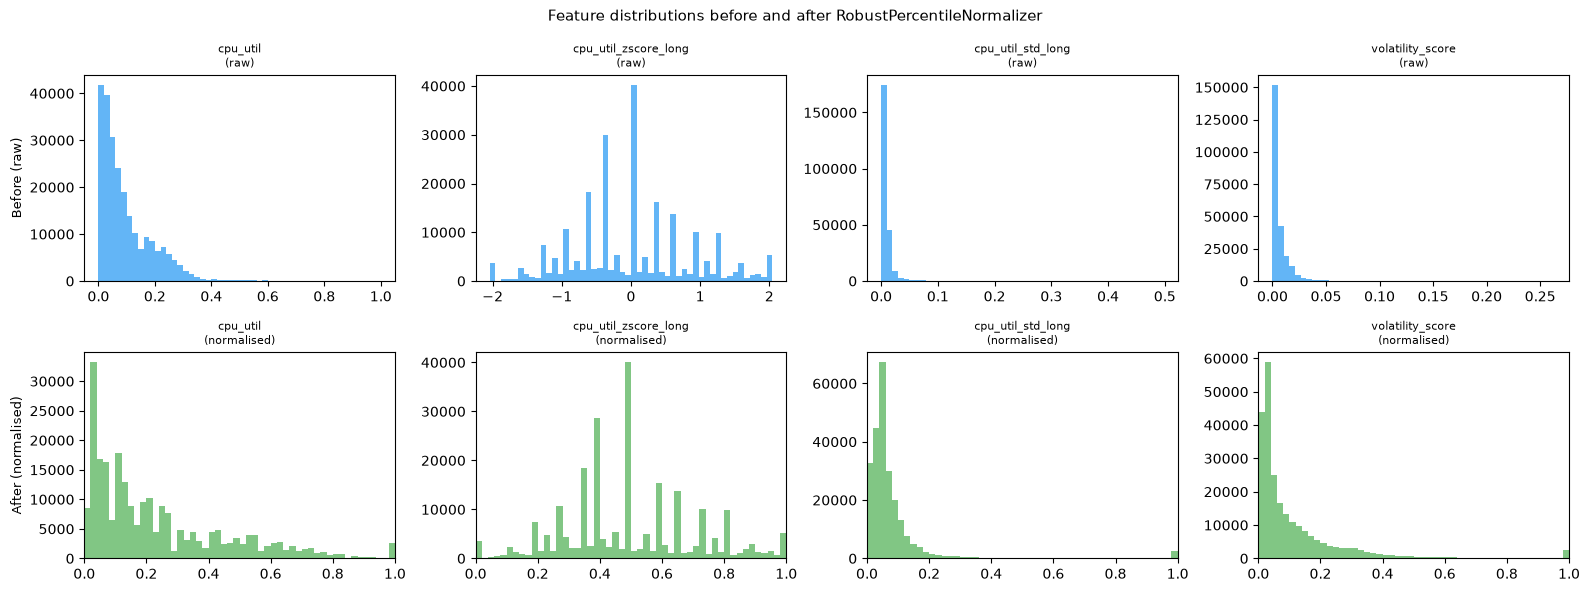

In [10]:
import matplotlib.pyplot as plt
sample_features = ['cpu_util', 'cpu_util_zscore_long', 'cpu_util_std_long', 'volatility_score']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, col in enumerate(sample_features):
    if col in train_df.columns:
        data_raw = train_df[col].replace([np.inf, -np.inf], np.nan).dropna()
        if len(data_raw) > 0:
            axes[0, i].hist(data_raw, bins=50, color='#2196F3', alpha=0.7, edgecolor='none')
        axes[0, i].set_title(f'{col}\n(raw)', fontsize=8)
    if col in train_norm.columns:
        data_norm = train_norm[col].replace([np.inf, -np.inf], np.nan).dropna()
        if len(data_norm) > 0:
            axes[1, i].hist(data_norm, bins=50, color='#4CAF50', alpha=0.7, edgecolor='none')
        axes[1, i].set_xlim(0, 1)
        axes[1, i].set_title(f'{col}\n(normalised)', fontsize=8)

axes[0, 0].set_ylabel('Before (raw)', fontsize=9)
axes[1, 0].set_ylabel('After (normalised)', fontsize=9)
fig.suptitle('Feature distributions before and after RobustPercentileNormalizer', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Save Feature Pipeline Artifact

The fitted pipeline is saved to `artifacts/feature_pipeline.joblib`.
It is loaded at API startup and applied to every incoming telemetry
snapshot before IF scoring.

In [11]:
save_feature_pipeline(pipeline)

# Verify round-trip
loaded_pipeline = load_feature_pipeline()
assert (loaded_pipeline.named_steps['normalizer'].bounds_.keys() ==
        pipeline.named_steps['normalizer'].bounds_.keys())

import os
size_kb = os.path.getsize('artifacts/feature_pipeline.joblib') / 1024
print(f'✓ Feature pipeline saved and verified')
print(f'  Artifact size: {size_kb:.1f} KB')
print(f'  Features:      {len(feature_cols)}')
print(f'  Fitted on:     {len(train_normal):,} training normal rows')

✓ Feature pipeline saved and verified
  Artifact size: 3.2 KB
  Features:      68
  Fitted on:     235,908 training normal rows


## Summary

| Step | Result |
|------|--------|
| Raw SMD metrics | 5 columns (cpu_util, mem_util, net_io_in, net_io_out, disk_io) |
| Feature engineering | 68 columns: 5 raw + 60 rolling + 3 cross-metric |
| Pipeline fit | 235,908 training normal rows, RobustPercentileNormalizer [p1, p99] |
| Known edge case | cpu_mem_corr_long NaN bounds — patched to (0.0, 1.0) at runtime |
| Artifact | `artifacts/feature_pipeline.joblib` (3.2 KB) |

**Feature count = 68 = TCN input_dim.** This is the contract between
the feature engineering pipeline and the deep learning model. If the
feature set changes, `input_dim` must be updated and both models retrained.

**Proceed to:** `03_isolation_forest.ipynb` (Day 4 training)